# Рубежный контроль №1
## Методы машинного обучения в АСОИУ. Вариант №4

**Задачи варианта:**

* **Задача №4.** Для набора данных провести кодирование одного (произвольного) категориального признака с использованием метода *label encoding*.
* **Задача №24.** Для набора данных для одного (произвольного) числового признака провести обнаружение и удаление выбросов на основе 5% и 95% квантилей.

**Используемый набор данных:** `penguins` (Palmer Archipelago Penguins) из библиотеки `seaborn`.

Датасет содержит измерения трёх видов пингвинов с островов архипелага Палмер (Антарктида). В нём присутствуют как категориальные признаки (`species`, `island`, `sex`), так и числовые (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`), что соответствует условиям обеих задач. 

## Подключение библиотек и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
data = sns.load_dataset('penguins')
print('Размер датасета:', data.shape)
data.head()

Размер датасета: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


---
# Задача №4. Label Encoding категориального признака

**Постановка:** провести кодирование одного произвольного категориального признака методом *label encoding*.

**Идея метода.** Каждому уникальному значению категориального признака ставится в соответствие целое число от $0$ до $n-1$, где $n$ — число уникальных категорий. В отличие от one-hot encoding, размерность пространства признаков не растёт, но между категориями появляется искусственный порядок, что нужно учитывать при выборе моделей.

**Выбранный признак:** `species` — вид пингвина (3 категории: *Adelie*, *Chinstrap*, *Gentoo*).

In [4]:
feature = 'species'
print('Уникальные значения признака:', data[feature].unique())
print('\nЧастоты:')
print(data[feature].value_counts())

Уникальные значения признака: <StringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str

Частоты:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


### Применение `LabelEncoder` из `sklearn.preprocessing`

In [5]:
le = LabelEncoder()
data['species_le'] = le.fit_transform(data[feature])

print('Соответствие категория → код:')
for code, category in enumerate(le.classes_):
    print(f'  {category!r:>12} -> {code}')

Соответствие категория → код:
      'Adelie' -> 0
   'Chinstrap' -> 1
      'Gentoo' -> 2


In [6]:
data[[feature, 'species_le']].head(10)

,species,species_le
0,Adelie,0
1,Adelie,0
2,Adelie,0
3,Adelie,0
4,Adelie,0
5,Adelie,0
6,Adelie,0
7,Adelie,0
8,Adelie,0
9,Adelie,0


### Проверка обратного преобразования
Метод `inverse_transform` восстанавливает исходные категориальные значения по их числовым кодам — это удобно при интерпретации результатов модели.

In [7]:
sample_codes = data['species_le'].head(5).values
print('Коды:           ', sample_codes)
print('Восстановленные:', le.inverse_transform(sample_codes))

Коды:            [0 0 0 0 0]
Восстановленные: ['Adelie' 'Adelie' 'Adelie' 'Adelie' 'Adelie']


### Визуализация результата кодирования

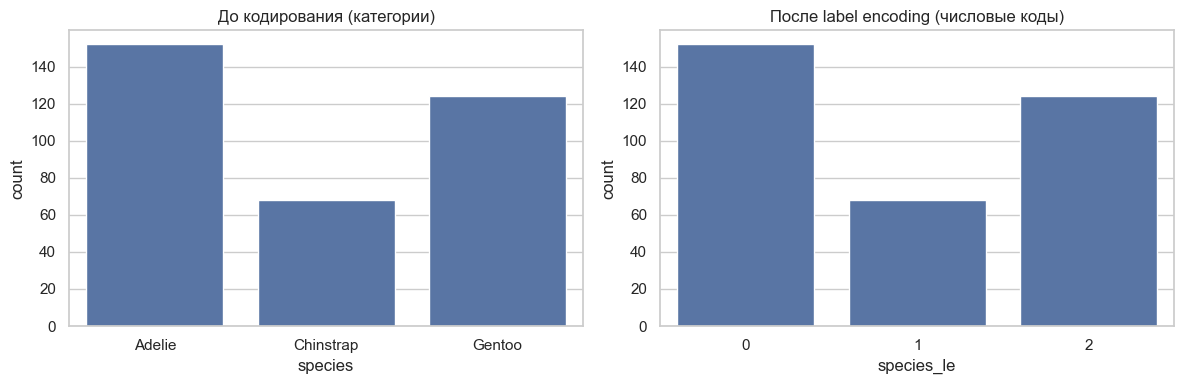

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=feature, data=data, ax=axes[0], order=le.classes_)
axes[0].set_title('До кодирования (категории)')

sns.countplot(x='species_le', data=data, ax=axes[1])
axes[1].set_title('После label encoding (числовые коды)')

plt.tight_layout()
plt.show()

**Вывод по задаче №4.** Признак `species` успешно закодирован методом *label encoding*: три категории (*Adelie*, *Chinstrap*, *Gentoo*) преобразованы в целочисленные значения $\{0, 1, 2\}$. Распределение количества наблюдений по классам сохранилось (что и ожидается — кодирование не изменяет состав данных, только их представление).

---
# Задача №24. Обнаружение и удаление выбросов по 5% и 95% квантилям

**Постановка:** для одного произвольного числового признака провести обнаружение и удаление выбросов на основе 5% и 95% квантилей.

**Идея метода.** Вычисляются квантили $Q_{0.05}$ и $Q_{0.95}$ — границы, между которыми лежит центральные 90% значений признака. Все наблюдения, у которых значение признака меньше $Q_{0.05}$ или больше $Q_{0.95}$, считаются выбросами и удаляются. Это простой и устойчивый подход, не требующий предположений о форме распределения (в отличие от метода $\mu \pm 3\sigma$).

**Выбранный признак:** `body_mass_g` — масса тела пингвина в граммах.

In [9]:
num_feature = 'body_mass_g'

df = data.dropna(subset=[num_feature]).copy()
print(f'Размер выборки до обработки: {len(df)}')
df[num_feature].describe()

Размер выборки до обработки: 342


count     342.000000
mean     4201.754386
std       801.954536
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4750.000000
max      6300.000000
Name: body_mass_g, dtype: float64

### Визуализация исходного распределения

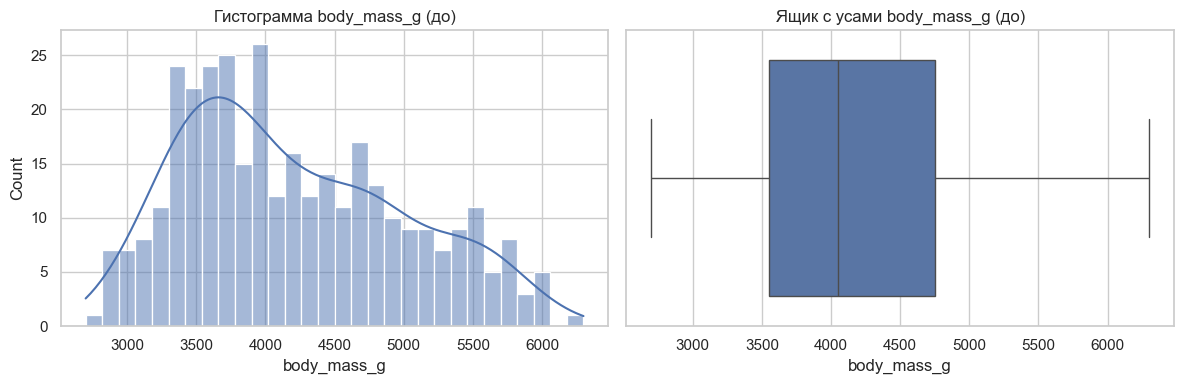

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[num_feature], kde=True, ax=axes[0], bins=30)
axes[0].set_title(f'Гистограмма {num_feature} (до)')

sns.boxplot(x=df[num_feature], ax=axes[1])
axes[1].set_title(f'Ящик с усами {num_feature} (до)')

plt.tight_layout()
plt.show()

### Расчёт 5% и 95% квантилей

In [11]:
q_low = df[num_feature].quantile(0.05)
q_high = df[num_feature].quantile(0.95)

print(f'5%  квантиль (нижняя граница): {q_low:.2f}')
print(f'95% квантиль (верхняя граница): {q_high:.2f}')

5%  квантиль (нижняя граница): 3150.00
95% квантиль (верхняя граница): 5650.00


### Идентификация выбросов

In [12]:
outliers_mask = (df[num_feature] < q_low) | (df[num_feature] > q_high)
outliers = df[outliers_mask]

print(f'Найдено выбросов: {len(outliers)} ({len(outliers) / len(df) * 100:.2f}% от выборки)')
print('\nПримеры выбросов:')
outliers[[num_feature, 'species', 'island', 'sex']].head(10)

Найдено выбросов: 34 (9.94% от выборки)

Примеры выбросов:


,body_mass_g,species,island,sex
42,3100.0,Adelie,Dream,Female
44,3000.0,Adelie,Dream,Female
47,2975.0,Adelie,Dream,NaN
54,2900.0,Adelie,Biscoe,Female
58,2850.0,Adelie,Biscoe,Female
64,2850.0,Adelie,Biscoe,Female
68,3050.0,Adelie,Torgersen,Female
98,2900.0,Adelie,Dream,Female
102,3075.0,Adelie,Biscoe,Female
104,2925.0,Adelie,Biscoe,Female


### Удаление выбросов

In [13]:
df_clean = df[~outliers_mask].copy()

print(f'Размер выборки до удаления выбросов:    {len(df)}')
print(f'Размер выборки после удаления выбросов: {len(df_clean)}')
print(f'Удалено объектов: {len(df) - len(df_clean)}')

Размер выборки до удаления выбросов:    342
Размер выборки после удаления выбросов: 308
Удалено объектов: 34


In [14]:
pd.concat(
    [df[num_feature].describe(), df_clean[num_feature].describe()],
    axis=1,
    keys=['Исходные', 'После очистки']
)

,Исходные,После очистки
count,342.000000,308.000000
mean,4201.754386,4178.814935
std,801.954536,688.117250
min,2700.000000,3150.000000
25%,3550.000000,3600.000000
50%,4050.000000,4050.000000
75%,4750.000000,4700.000000
max,6300.000000,5650.000000


### Сравнение распределений до и после очистки

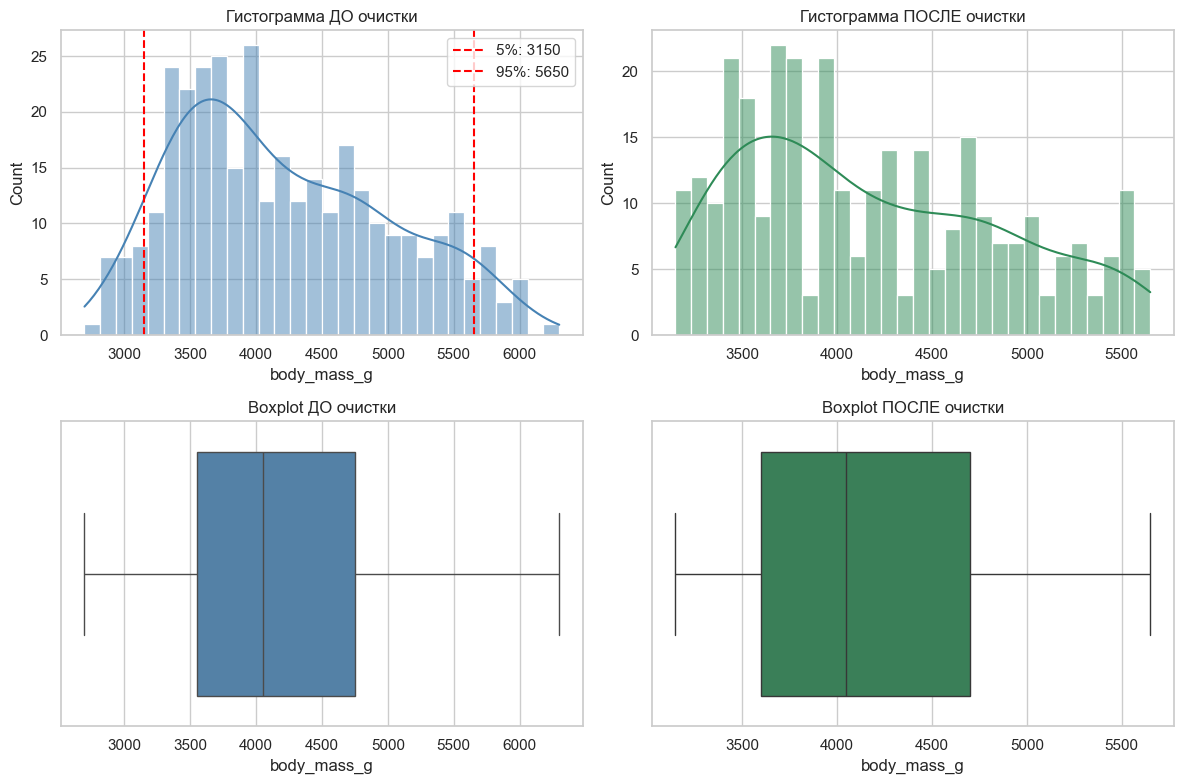

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df[num_feature], kde=True, ax=axes[0, 0], bins=30, color='steelblue')
axes[0, 0].axvline(q_low, color='red', linestyle='--', label=f'5%: {q_low:.0f}')
axes[0, 0].axvline(q_high, color='red', linestyle='--', label=f'95%: {q_high:.0f}')
axes[0, 0].legend()
axes[0, 0].set_title('Гистограмма ДО очистки')

sns.histplot(df_clean[num_feature], kde=True, ax=axes[0, 1], bins=30, color='seagreen')
axes[0, 1].set_title('Гистограмма ПОСЛЕ очистки')

sns.boxplot(x=df[num_feature], ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Boxplot ДО очистки')

sns.boxplot(x=df_clean[num_feature], ax=axes[1, 1], color='seagreen')
axes[1, 1].set_title('Boxplot ПОСЛЕ очистки')

plt.tight_layout()
plt.show()

**Вывод по задаче №24.** На основе 5% и 95% квантилей признака `body_mass_g` определены границы $[Q_{0.05},\,Q_{0.95}]$, за пределами которых наблюдения считаются выбросами. Эти объекты удалены из выборки. На графиках видно, что после очистки распределение признака стало компактнее, на boxplot исчезли точки за границами усов, а описательные статистики (`min`, `max`, стандартное отклонение) изменились в ожидаемую сторону. Отметим, что метод по построению удаляет около 10% данных (по 5% с каждого конца), поэтому применять его следует обдуманно — особенно когда «выбросы» могут нести содержательную информацию.

---
## Итоги

1. **Задача №4** решена: категориальный признак `species` закодирован методом `LabelEncoder` из `sklearn.preprocessing`, получены целочисленные коды $\{0, 1, 2\}$, проверено обратное преобразование.
2. **Задача №24** решена: для числового признака `body_mass_g` рассчитаны 5% и 95% квантили, идентифицированы и удалены значения, выходящие за эти границы; распределение признака после очистки визуализировано и сравнено с исходным.
